In [1]:
import matplotlib.pyplot as plt
import numpy as np
import openmc

In [12]:
sp = openmc.StatePoint('statepoint.100.h5')
current = sp.get_tally(name = 'current')
print(current)
rxns = sp.get_tally(name = 'reactions')
print(rxns)
heat = sp.get_tally(name = 'heat_source')
print(heat)
width = 100
shape = (width,width,width)
sp.close()

Tally
	ID             =	1
	Name           =	current
	Filters        =	MeshFilter, ParticleFilter
	Nuclides       =	total
	Scores         =	['current', 'flux']
	Estimator      =	analog
	Multiply dens. =	True
Tally
	ID             =	2
	Name           =	reactions
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['coherent-scatter', 'incoherent-scatter', 'photoelectric', 'pair-production', 'heating']
	Estimator      =	collision
	Multiply dens. =	True
Tally
	ID             =	3
	Name           =	heat_source
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['coherent-scatter', 'incoherent-scatter']
	Estimator      =	tracklength
	Multiply dens. =	True


In [13]:
np.sum(heat.get_slice(scores=['coherent-scatter']).mean)


np.float64(0.06998254219259226)

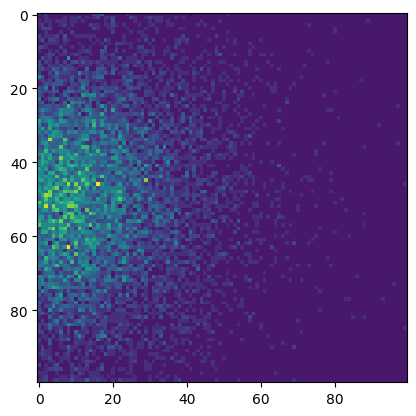

In [14]:
photo = current.get_slice(scores = ['current'])
photo.mean.shape = shape
photo = np.array(photo.mean)
plt.imshow(photo[-1,:,:])

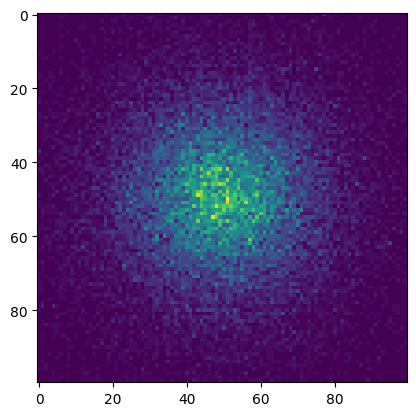

In [188]:
photo = rxns.get_slice(scores = ['photoelectric'])
photo.mean.shape = shape
photo = np.array(photo.mean)
plt.imshow(photo[:,:,25])